In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# The goal is to model wine quality based on physicochemical tests

from ucimlrepo import fetch_ucirepo

wine = fetch_ucirepo(id=186)

In [3]:
print(type(wine))
print()
print(wine.shape)
print()
print(wine.keys())

<class 'ucimlrepo.dotdict.dotdict'>

None

dict_keys(['data', 'metadata', 'variables'])


In [4]:
# Understanding the Data 

print(wine.data.keys())
print()
for key, values in wine.metadata.items():
    print(f'{key}: {values}\n')
print()
print(wine.variables)

dict_keys(['ids', 'features', 'targets', 'original', 'headers'])

uci_id: 186

name: Wine Quality

repository_url: https://archive.ics.uci.edu/dataset/186/wine+quality

data_url: https://archive.ics.uci.edu/static/public/186/data.csv

abstract: Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).

area: Business

tasks: ['Classification', 'Regression']

characteristics: ['Multivariate']

num_instances: 4898

num_features: 11

feature_types: ['Real']

demographics: []

target_col: ['quality']

index_col: None

has_missing_values: no

missing_values_symbol: None

year_of_dataset_creation: 2009

last_updated: Wed Nov 15 2023

dataset_doi: 10.24432/C56S3T

creators: ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis']

intro_paper: {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine pref

In [5]:
# convert to df for visualisation and exploration
df = pd.DataFrame(wine.data.features, columns=wine.data.headers)
df['quality']= wine.data.targets

df.head(4)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,NaN
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,NaN
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,NaN
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,NaN


In [6]:
# Checking the Categorical out

print(df['color'].dtype)

print(df['color'].value_counts())

float64
Series([], Name: count, dtype: int64)


In [7]:
# dropping color since it is empty 
df.drop('color', axis=1, inplace=True)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB
None


In [8]:
# check for null

df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
# Check for duplicates

print(df.duplicated().sum())
print()

df[df.duplicated()]

1179



,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.400000,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.500000,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.500000,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.500000,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.900000,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6427,6.4,0.230,0.35,10.30,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
6449,7.0,0.360,0.35,2.50,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
6450,6.4,0.330,0.44,8.90,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
6455,7.1,0.230,0.39,13.70,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [10]:
# dropping duplicates

df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 5318 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         5318 non-null   float64
 1   volatile_acidity      5318 non-null   float64
 2   citric_acid           5318 non-null   float64
 3   residual_sugar        5318 non-null   float64
 4   chlorides             5318 non-null   float64
 5   free_sulfur_dioxide   5318 non-null   float64
 6   total_sulfur_dioxide  5318 non-null   float64
 7   density               5318 non-null   float64
 8   pH                    5318 non-null   float64
 9   sulphates             5318 non-null   float64
 10  alcohol               5318 non-null   float64
 11  quality               5318 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 540.1 KB


In [11]:
df.describe()

# the range of min and max is large so scaling will be required
# some features have extreme max values which suggest normalization and Transformation might be needed
# Some features (like density and alcohol) are inversely related, correlation analysis can reveal redundancy.
# The target variable quality is discrete and slightly imbalanced (most wines rated 5–6)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000,5318.000000
mean,7.215523,0.344171,0.318522,5.049605,0.056700,30.030463,114.107747,0.994536,3.224639,0.533402,10.549222,5.795600
std,1.319777,0.168264,0.147177,4.500645,0.036865,17.804365,56.783848,0.002966,0.160403,0.149753,1.185964,0.879715
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994660,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.750000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


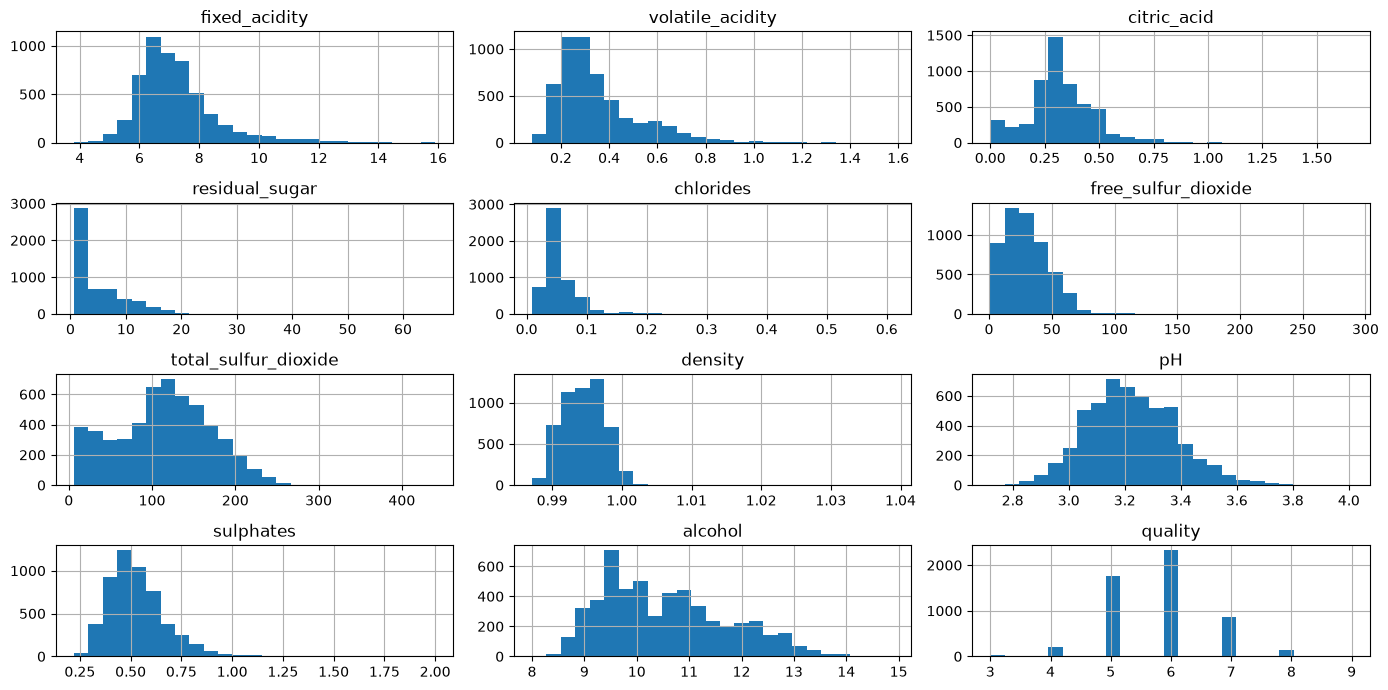

In [12]:
# lets visualise with histogram since its all numeric

df.hist(bins=25, figsize=(14, 7))
plt.tight_layout()
plt.show()

# Based on Plot
# The histogram plots show that several features (volatile_acidity, residual_sugar, chlorides, free_sulfur_dioxide, total_sulfur_dioxide) 
# are strongly right‑skewed with long tails and contain extreme but valid outliers. 
# pH is fairly symmetric and evenly distributed. 
# Quality is discrete, imbalanced, and exhibits multiple peaks.
# Overall, most physicochemical variables contain rare extreme values that represent real observations rather than noise.

In [13]:
# checking for skewness

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_cols = df.select_dtypes(include=['object', 'str']).columns.to_list()

print('Numerical Columns: ', num_cols)
print('Categorical Columns: ', cat_cols)

Numerical Columns:  ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Categorical Columns:  []


In [14]:
# confirming skewed values

skewed = df.skew(numeric_only=True)
skewed_cols = skewed[skewed > 1].index.to_list()

print('Skewed Colunms: ', skewed_cols)
print()
skewed

Skewed Colunms:  ['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'sulphates']



fixed_acidity           1.650055
volatile_acidity        1.504115
citric_acid             0.483817
residual_sugar          1.706027
chlorides               5.339077
free_sulfur_dioxide     1.363772
total_sulfur_dioxide    0.063667
density                 0.666033
pH                      0.390358
sulphates               1.809099
alcohol                 0.545866
quality                 0.147470
dtype: float64

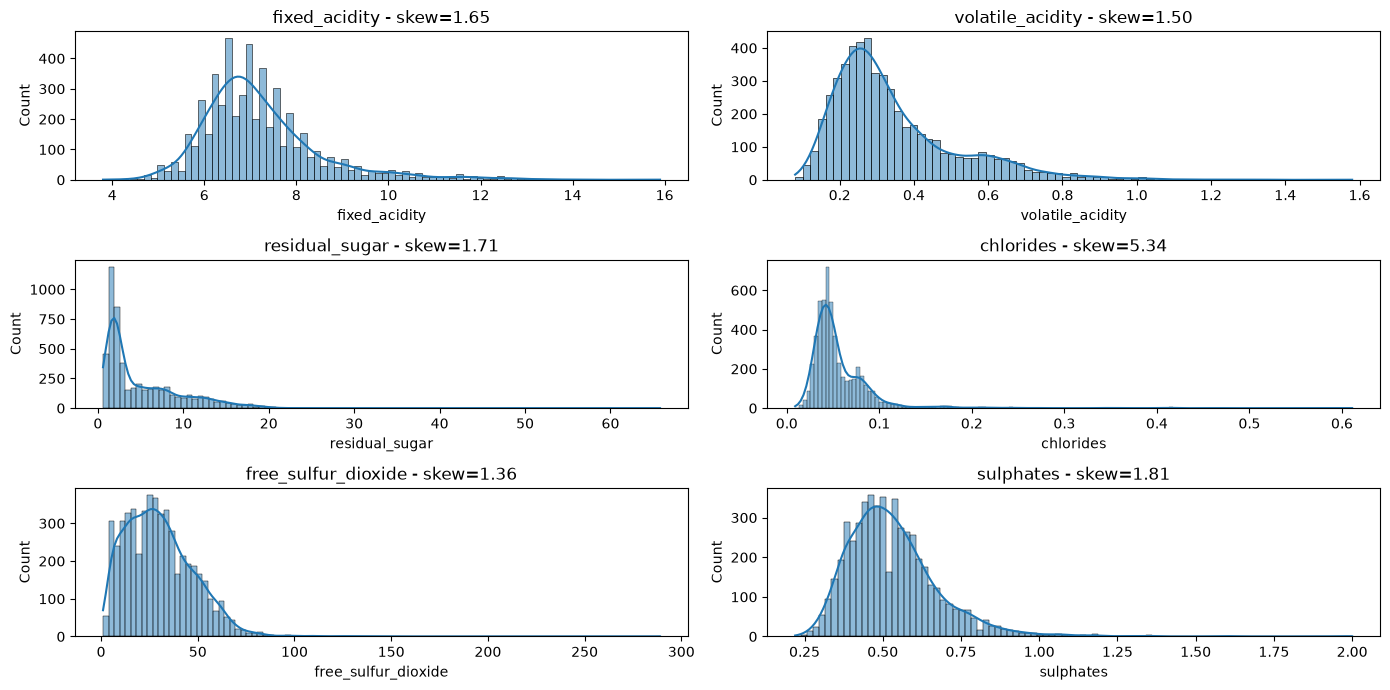

In [15]:
# plotting skewed values

fig, axes = plt.subplots(3, 2, figsize=(14, 7))
axes = axes.flatten()

for col, ax in zip(skewed_cols, axes):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'{col} - skew={df[col].skew():.2f}')

plt.tight_layout()
plt.show()

In [16]:
# checking for outliers using IQR

outlier_cols = []
no_outlier_cols = []
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        outlier_cols.append(col)
    else:
        no_outlier_cols.append(col)

    outlier_summary.append({
        'Columns': col,
        'Outlier Count': len(outliers),
        'Total Row': len(df),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })

print("Columns with outliers:", outlier_cols)
print()
print("Columns without outliers:", no_outlier_cols)
print()

outlier_table = pd.DataFrame(outlier_summary)
outlier_table.sort_values(by='Outlier Count', ascending=False)

Columns with outliers: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Columns without outliers: []



,Columns,Outlier Count,Total Row,Outlier %
0,fixed_acidity,304,5318,5.72
1,volatile_acidity,279,5318,5.25
4,chlorides,237,5318,4.46
11,quality,183,5318,3.44
9,sulphates,163,5318,3.07
2,citric_acid,143,5318,2.69
3,residual_sugar,141,5318,2.65
8,pH,49,5318,0.92
5,free_sulfur_dioxide,44,5318,0.83
6,total_sulfur_dioxide,10,5318,0.19


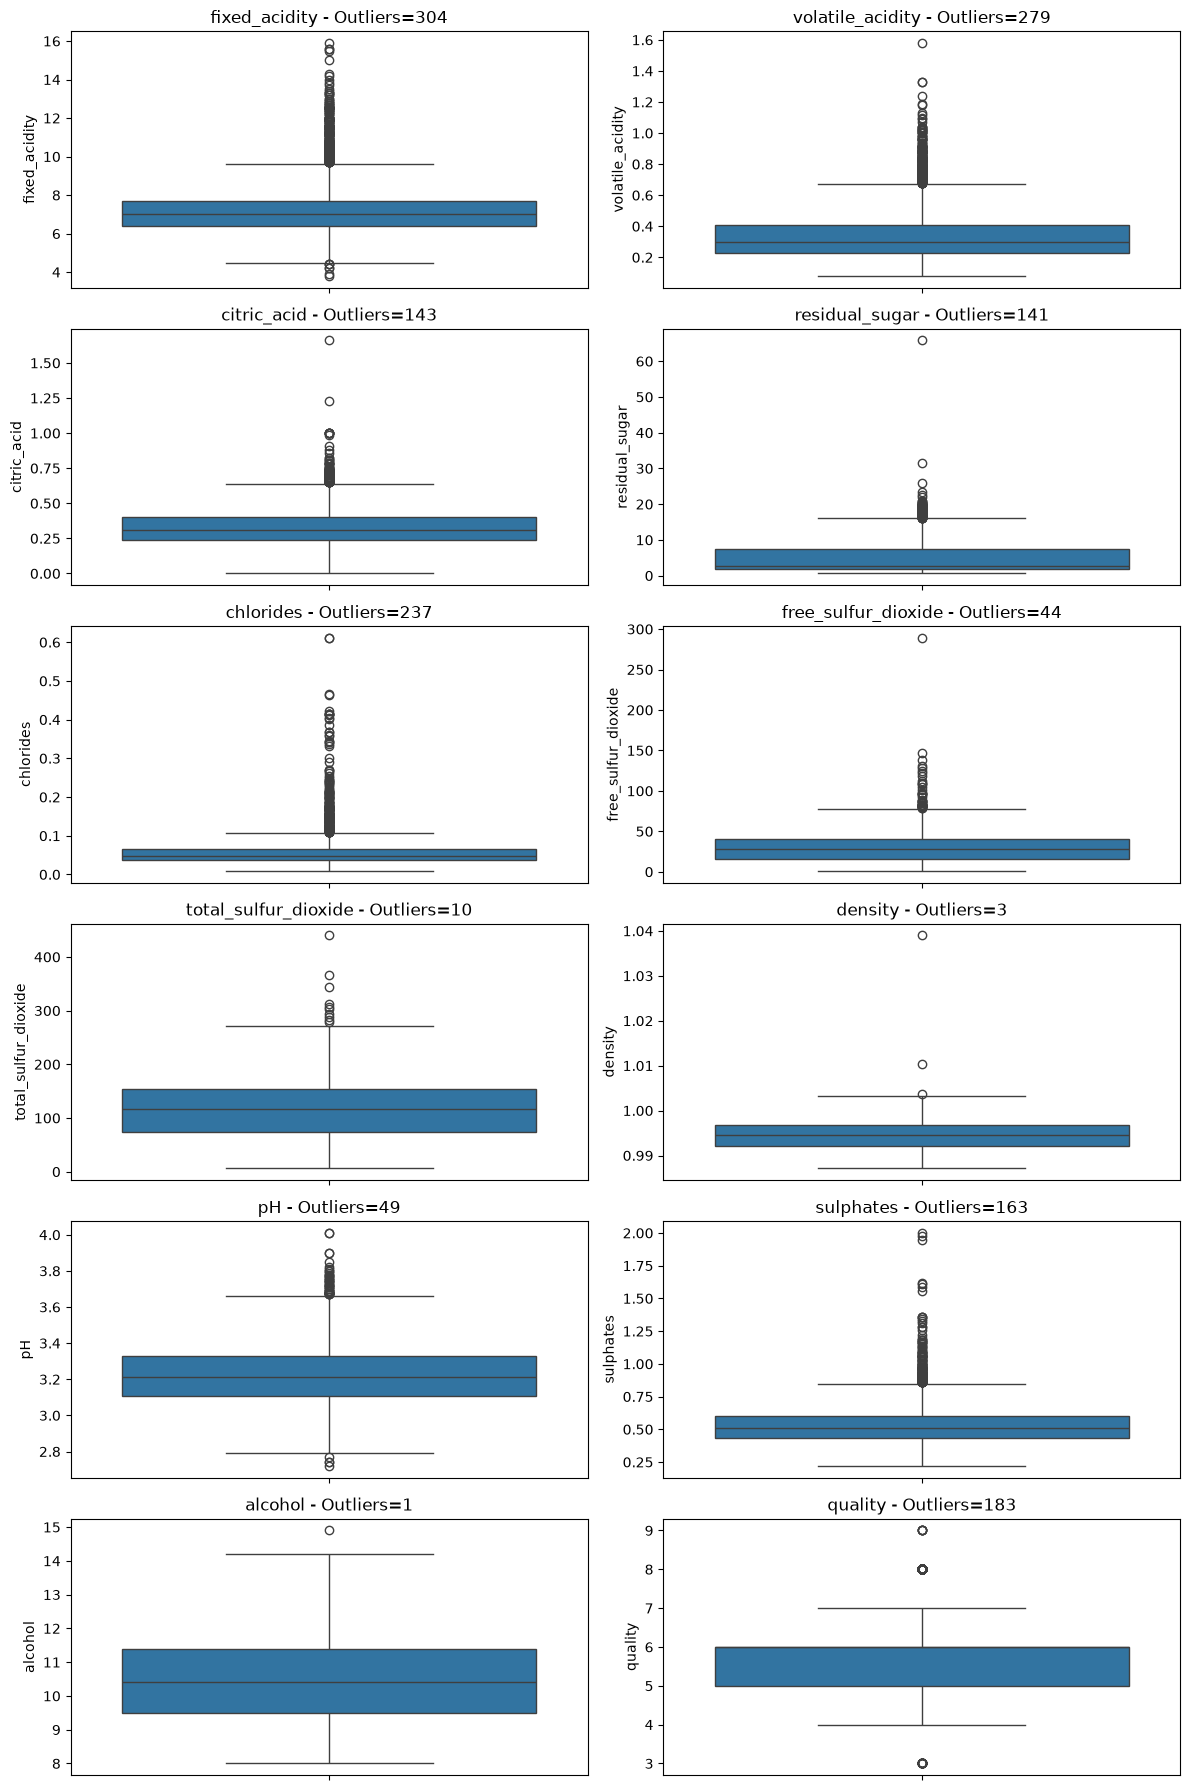

In [17]:
# Using boxplot to visualise Outliers

fig, axes = plt.subplots(6, 2, figsize=(12, 18))
axes = axes.flatten()

for col, ax in zip(outlier_cols, axes):
    sns.boxplot(df[col], ax=ax)

    # get outlier count for this column
    count = outlier_table.loc[outlier_table['Columns'] == col, 'Outlier Count'].values[0]

    ax.set_title(f'{col} - Outliers={count}')

# hide unused axes
for ax in axes[len(outlier_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# checking for correlations
df_corr = df.corr(numeric_only=True)
df_corr['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.469216
citric_acid             0.097926
free_sulfur_dioxide     0.054199
sulphates               0.042040
pH                      0.039789
total_sulfur_dioxide   -0.050183
residual_sugar         -0.056824
fixed_acidity          -0.080190
chlorides              -0.201960
volatile_acidity       -0.265354
density                -0.326301
Name: quality, dtype: float64

In [19]:
# Based on the above we note alcohol has the best correlation others are not correlated, everything has an outlier and 
# six of the columns has skewness which are meaningful.

# The goal is to predict wine quality based on physicochemical tests the data is ordered but imbalanced the most common wines 
# are ordinary rather than poor.

# deciding on model loss function and metrics

'''

The wine quality dataset is best modeled as a regression problem because the target variable is numeric, ordered, and not categorical. 
 Alcohol shows the strongest correlation with quality, while other features have weak but meaningful nonlinear relationships that 
 tree‑based models can capture. 
 The dataset contains right‑skewed distributions and real outliers, so robust methods such as Random Forest or Gradient Boosting are appropriate. 
 For evaluation, MAE, RMSE, and R² are the correct regression metrics. No features should be removed at this stage; 
 instead, scaling or transformation may be applied depending on the model. Overall, a nonlinear ensemble regressor with robust 
 evaluation metrics is the most suitable approach.

'''

'\n\nThe wine quality dataset is best modeled as a regression problem because the target variable is numeric, ordered, and not categorical. \n Alcohol shows the strongest correlation with quality, while other features have weak but meaningful nonlinear relationships that \n tree‑based models can capture. \n The dataset contains right‑skewed distributions and real outliers, so robust methods such as Random Forest or Gradient Boosting are appropriate. \n For evaluation, MAE, RMSE, and R² are the correct regression metrics. No features should be removed at this stage; \n instead, scaling or transformation may be applied depending on the model. Overall, a nonlinear ensemble regressor with robust \n evaluation metrics is the most suitable approach.\n\n'

In [20]:
# splitting data 
from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [21]:
# SVR Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

svr_preprocess = Pipeline([
    ('scaler', RobustScaler())
])


In [22]:
X_train_scaled = svr_preprocess.fit_transform(X_train)
X_test_scaled = svr_preprocess.transform(X_test)

# C=1 → gentle, smooth C=10 → balance, C=100 → strict, aggressive

from sklearn.svm import SVR

# Linear SVR (gamma ignored)
lsvr1 = SVR(kernel='linear', C=1, epsilon=0.1)
lsvr2 = SVR(kernel='linear', C=10, epsilon=0.1)
lsvr3 = SVR(kernel='linear', C=100, epsilon=0.1)

# RBF SVR (gamma matters)
rsvr1 = SVR(kernel='rbf', C=1, gamma=0.1, epsilon=0.1)
rsvr2 = SVR(kernel='rbf', C=10, gamma=0.1, epsilon=0.1)
rsvr3 = SVR(kernel='rbf', C=100, gamma=0.5, epsilon=0.1)

models = [lsvr1, lsvr2, lsvr3, rsvr1, rsvr2, rsvr3]

for m in models:
    m.fit(X_train_scaled, y_train)

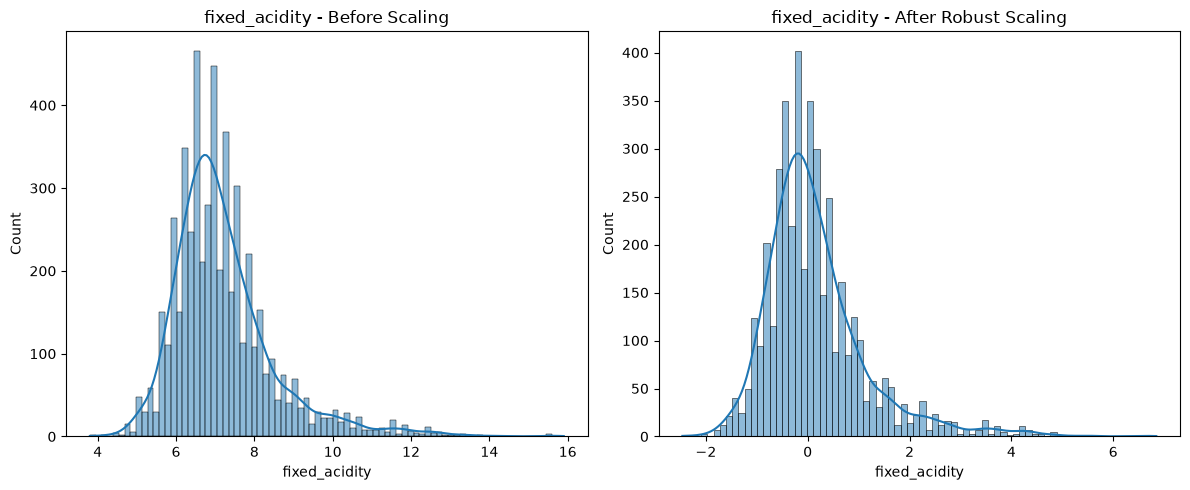

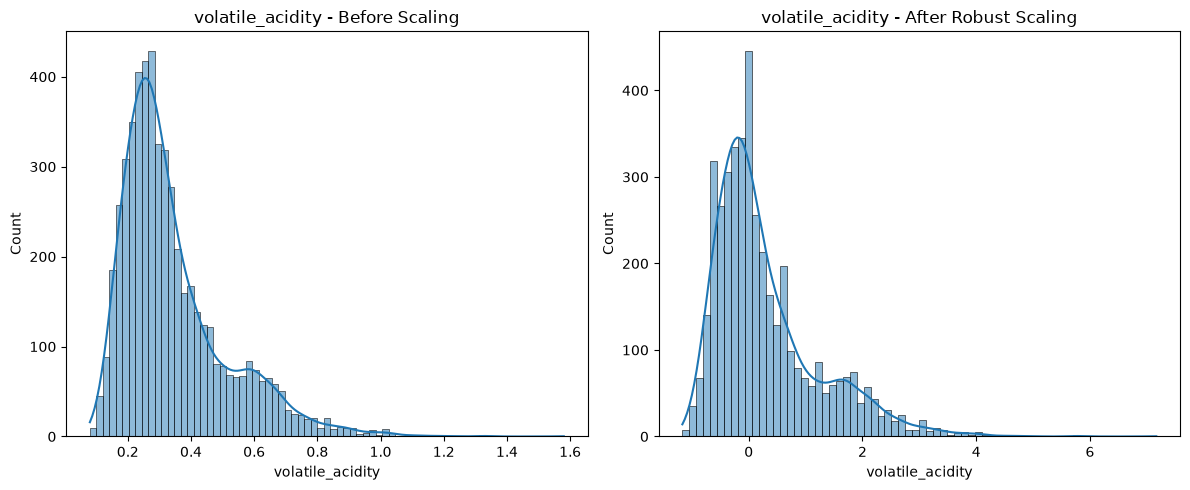

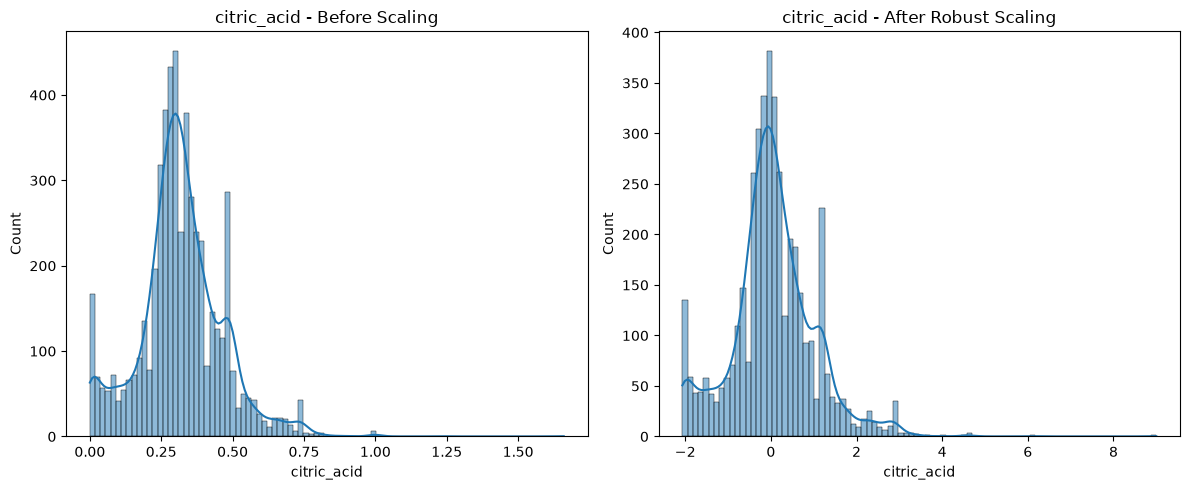

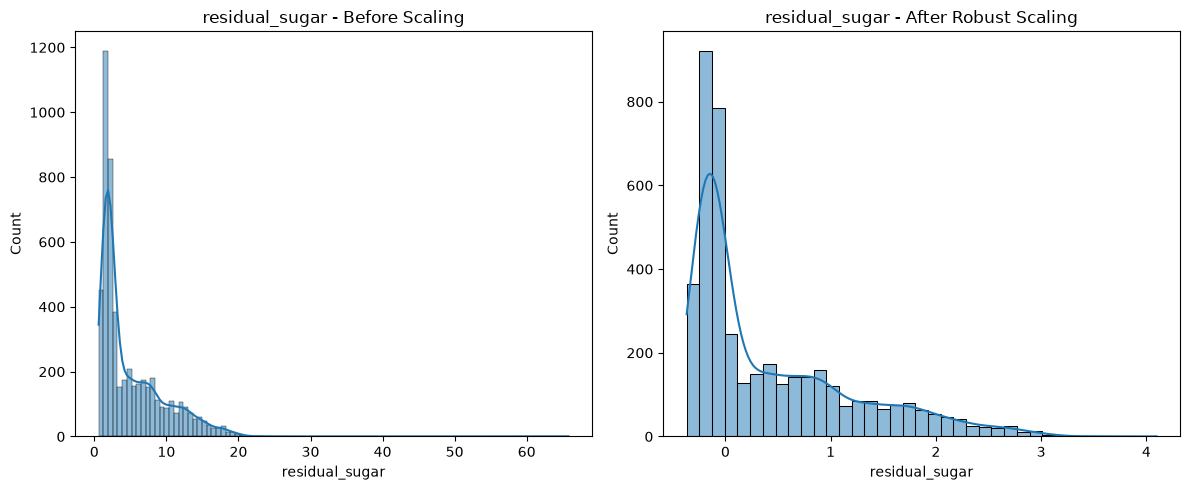

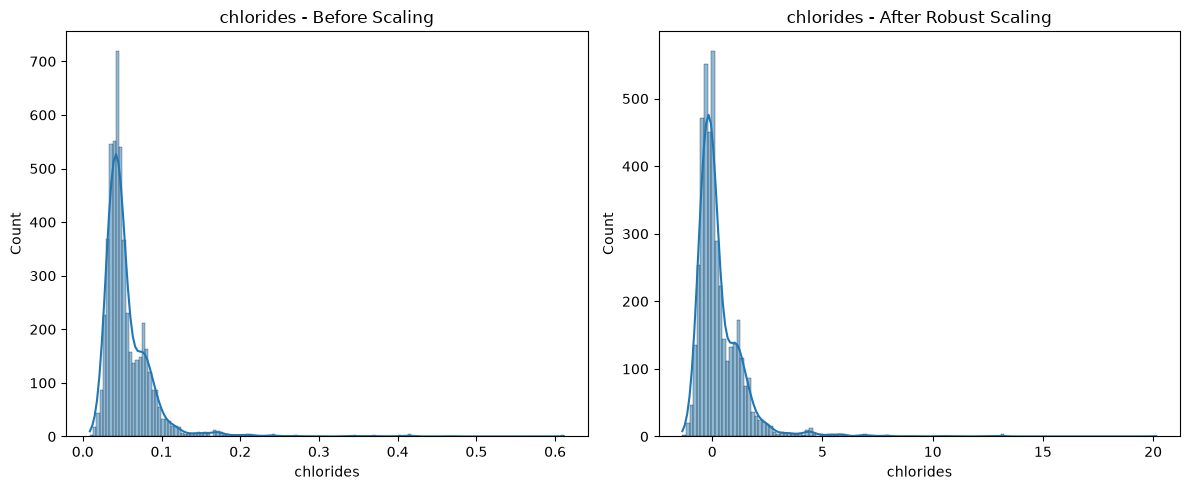

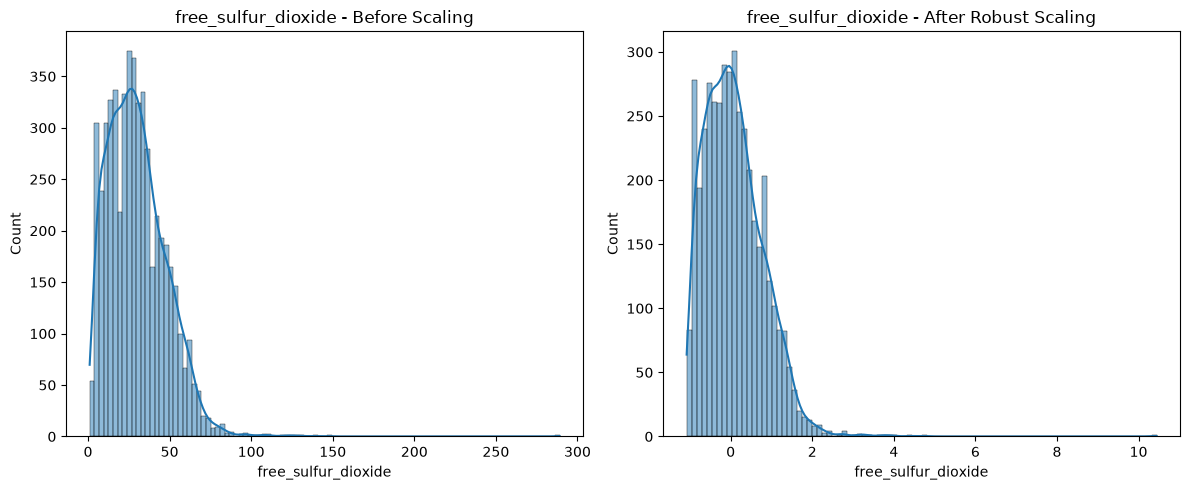

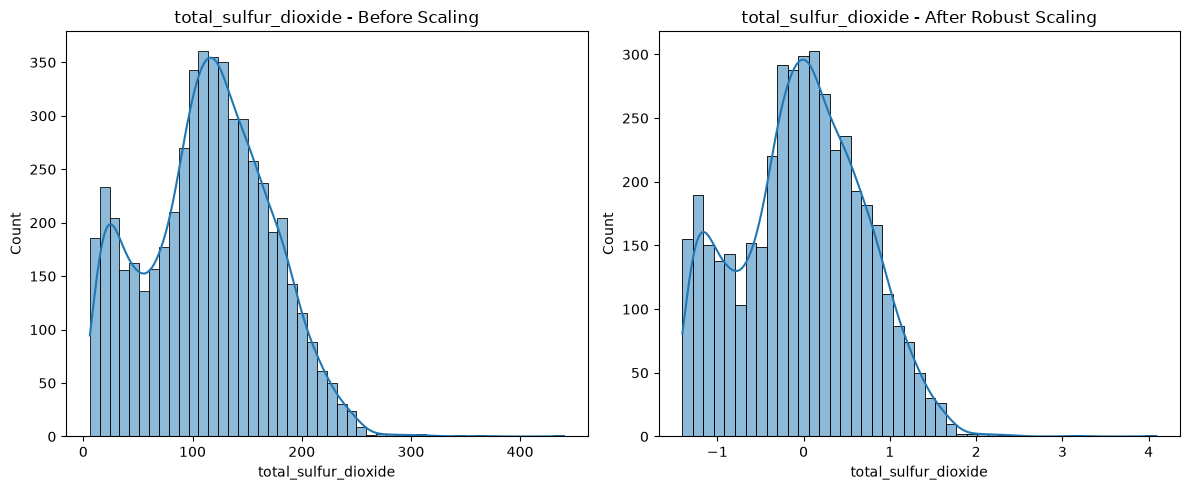

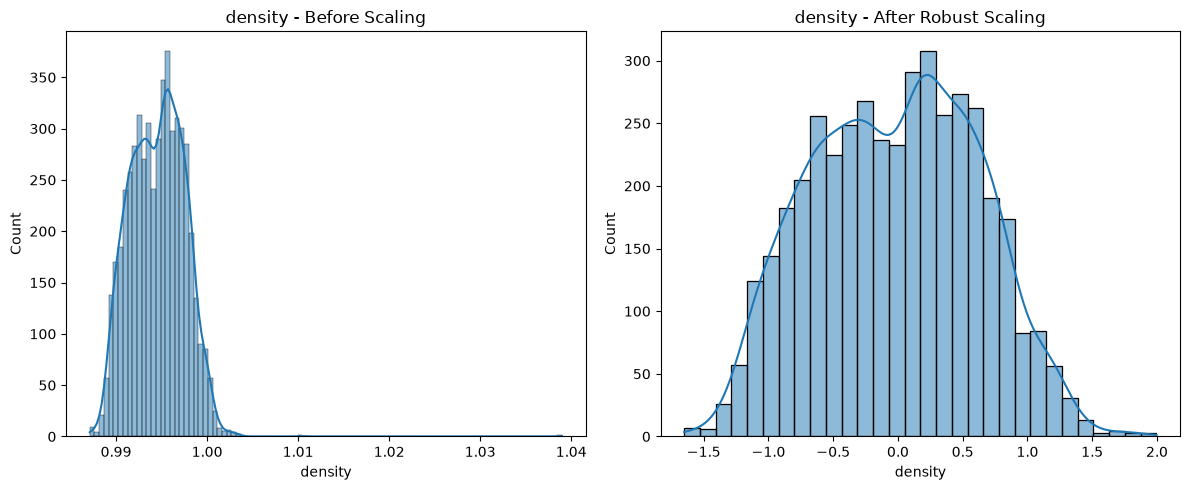

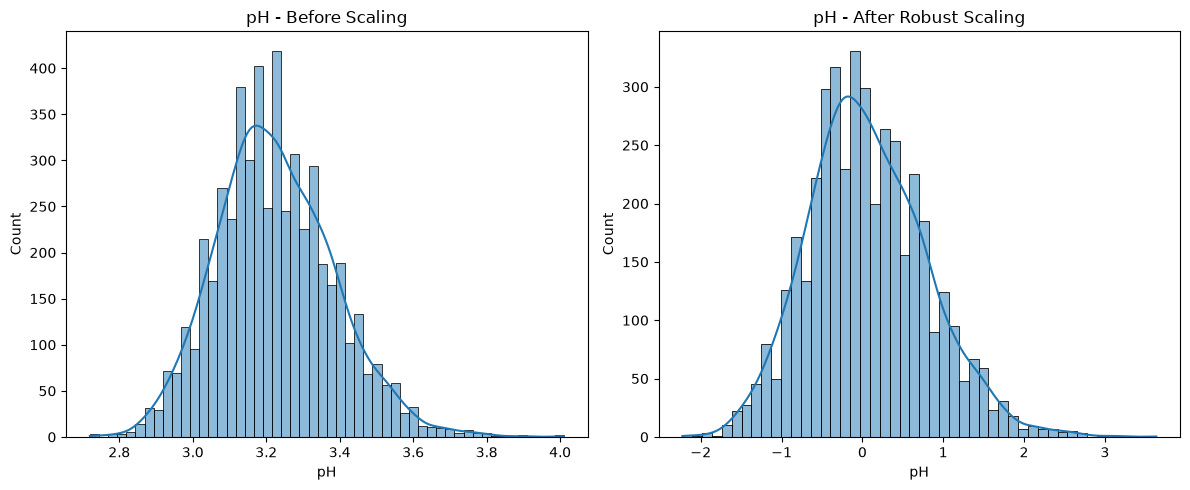

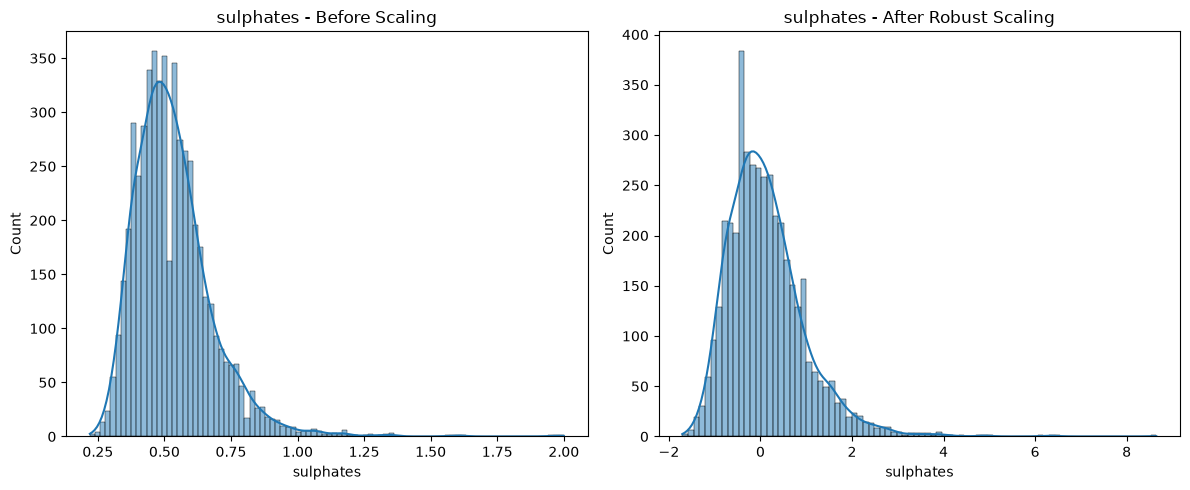

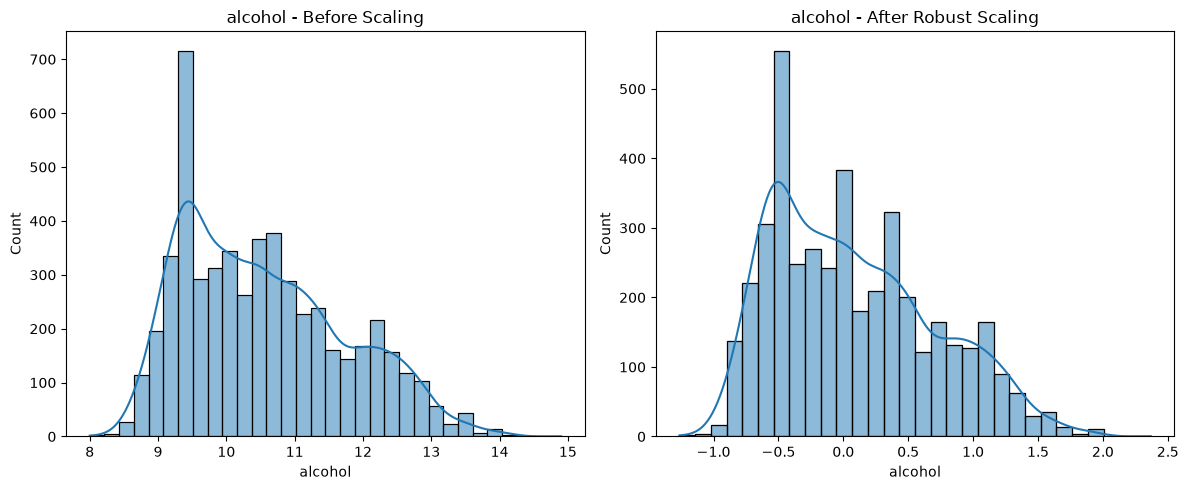

In [23]:
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

num_cols = X.columns.tolist()   # FIXED

for col in num_cols:
    plt.figure(figsize=(12, 5))

    # Before scaling
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} - Before Scaling")

    # After scaling
    plt.subplot(1, 2, 2)
    sns.histplot(scaled_df[col], kde=True)
    plt.title(f"{col} - After Robust Scaling")

    plt.tight_layout()
    plt.show()


In [24]:
from sklearn.svm import SVR

lsvr1 = SVR(kernel='linear', C=1, epsilon=0.1)
lsvr2 = SVR(kernel='linear', C=10, epsilon=0.1)
lsvr3 = SVR(kernel='linear', C=100, epsilon=0.1)

rsvr1 = SVR(kernel='rbf', C=1, epsilon=0.1, gamma=0.1)
rsvr2 = SVR(kernel='rbf', C=1, epsilon=0.1, gamma=0.5)
rsvr3 = SVR(kernel='rbf', C=1, epsilon=0.1, gamma=1)
rsvr4 = SVR(kernel='rbf', C=10, epsilon=0.1, gamma=0.1)
rsvr5 = SVR(kernel='rbf', C=10, epsilon=0.1, gamma=0.5)
rsvr6 = SVR(kernel='rbf', C=10, epsilon=0.1, gamma=1)
rsvr7 = SVR(kernel='rbf', C=100, epsilon=0.1, gamma=0.1)
rsvr8 = SVR(kernel='rbf', C=100, epsilon=0.1, gamma=0.5)
rsvr9 = SVR(kernel='rbf', C=100, epsilon=0.1, gamma=1)

models =  [lsvr1, lsvr2, lsvr3, rsvr1, rsvr2, rsvr3, rsvr4, rsvr5, rsvr6, rsvr7, rsvr8, rsvr9]

for model in models:
    model.fit(X_train_scaled, y_train)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
models = {
    'Linear, C=1 gamma=0.1': lsvr1,
    'Linear, C=1 gamma=0.5': lsvr2,
    'Linear, C=1 gamma=1': lsvr3,
    'RBF, C=1 gamma=0.1': rsvr1,
    'RBF, C=1 gamma=0.5': rsvr2,
    'RBF, C=1 gamma=1': rsvr3,
    'RBF, C=10 gamma=0.1': rsvr4,
    'RBF, C=10 gamma=0.5': rsvr5,
    'RBF, C=10 gamma=1': rsvr6,
    'RBF, C=100 gamma=0.1': rsvr7,
    'RBF, C=100 gamma=0.5': rsvr8,
    'RBF, C=100 gamma=1': rsvr9,}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

svr_result = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
svr_result

,Model,MAE,RMSE,R2
0,"Linear, C=1 gamma=0.1",0.552174,0.715425,0.317710
1,"Linear, C=1 gamma=0.5",0.552207,0.715451,0.317660
2,"Linear, C=1 gamma=1",0.552204,0.715448,0.317666
3,"RBF, C=1 gamma=0.1",0.507138,0.677791,0.387605
4,"RBF, C=1 gamma=0.5",0.531019,0.704138,0.339070
5,"RBF, C=1 gamma=1",0.541925,0.711495,0.325186
6,"RBF, C=10 gamma=0.1",0.524032,0.698617,0.349393
7,"RBF, C=10 gamma=0.5",0.585646,0.758177,0.233729
8,"RBF, C=10 gamma=1",0.582145,0.760567,0.228892
9,"RBF, C=100 gamma=0.1",0.585099,0.771999,0.205536


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test =  train_test_split(X, y, shuffle=True, test_size=0.2, random_state=42)

results=[]

tree1 = DecisionTreeRegressor()
tree2 = DecisionTreeRegressor(random_state=42)
tree3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree4 = DecisionTreeRegressor(max_depth=5, random_state=42)
tree5 = DecisionTreeRegressor(max_depth=5, random_state=42)

forest1 = RandomForestRegressor()
forest2 = RandomForestRegressor(n_estimators=100, random_state=42)
forest3 = RandomForestRegressor(n_estimators=200, random_state=42)
forest4 = RandomForestRegressor(n_estimators=300, max_depth=2, random_state=0)
forest5 = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
forest6 = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
forest7 = RandomForestRegressor(n_estimators=500, max_depth=2, random_state=0)
forest8 = RandomForestRegressor(n_estimators=500, max_depth=5, random_state=42)
forest9 = RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42)

models = {
    'Decision Tree (No depth): ': tree1,
    'Decision Tree (random_state=42): ': tree2,
    'Decision Tree (max_depth=2): ': tree3,
    'Decision Tree (max_depth=5): ': tree4,
    'Decision Tree (max_depth=2): ': tree5,
    'Random Forest (No depth): ': forest1,
    'Random Forest (100 trees): ': forest2,
    'Random Forest (200 trees): ': forest3,
    'Random Forest (300 trees, depth=2): ': forest4,
    'Random Forest (300 trees, depth=5): ': forest5,
    'Random Forest (300 trees, depth=10): ': forest6,
    'Random Forest (500 trees, depth=2): ': forest7,
    'Random Forest (500 trees, depth=5): ': forest8,
    'Random Forest (500 trees, depth=10): ': forest9,
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae= mean_absolute_error(y_test, pred)
    rmse= np.sqrt(mean_squared_error(y_test, pred))
    r2= r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

tf_table = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
tf_table

,Model,MAE,RMSE,R2
0,Decision Tree (No depth):,0.681391,0.971879,-0.259114
1,Decision Tree (random_state=42):,0.680451,0.967518,-0.247838
2,Decision Tree (max_depth=2):,0.556297,0.732130,0.285475
3,Decision Tree (max_depth=5):,0.556297,0.732130,0.285475
4,Random Forest (No depth):,0.507660,0.672927,0.396361
5,Random Forest (100 trees):,0.509878,0.673774,0.394842
6,Random Forest (200 trees):,0.509648,0.674061,0.394325
7,"Random Forest (300 trees, depth=2):",0.593009,0.756394,0.237330
8,"Random Forest (300 trees, depth=5):",0.541649,0.706468,0.334688
9,"Random Forest (300 trees, depth=10):",0.516125,0.678156,0.386945


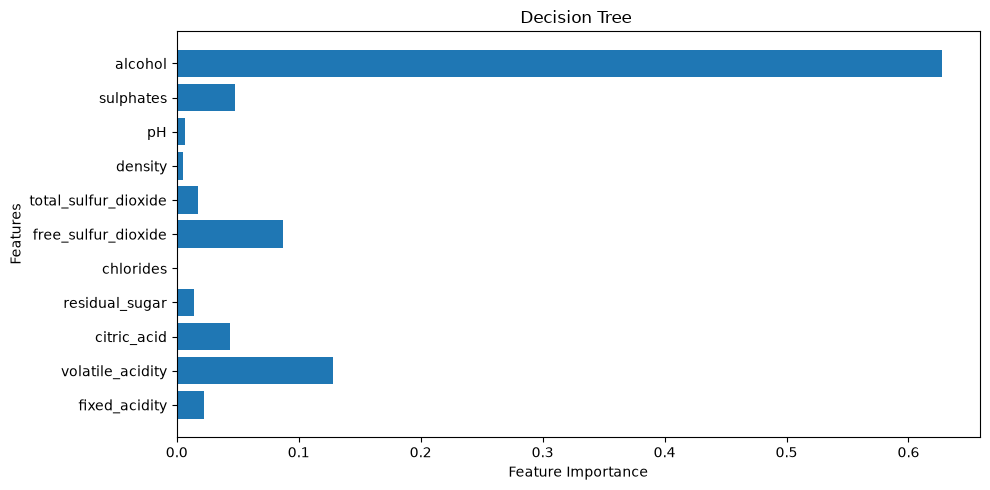

<Figure size 640x480 with 0 Axes>

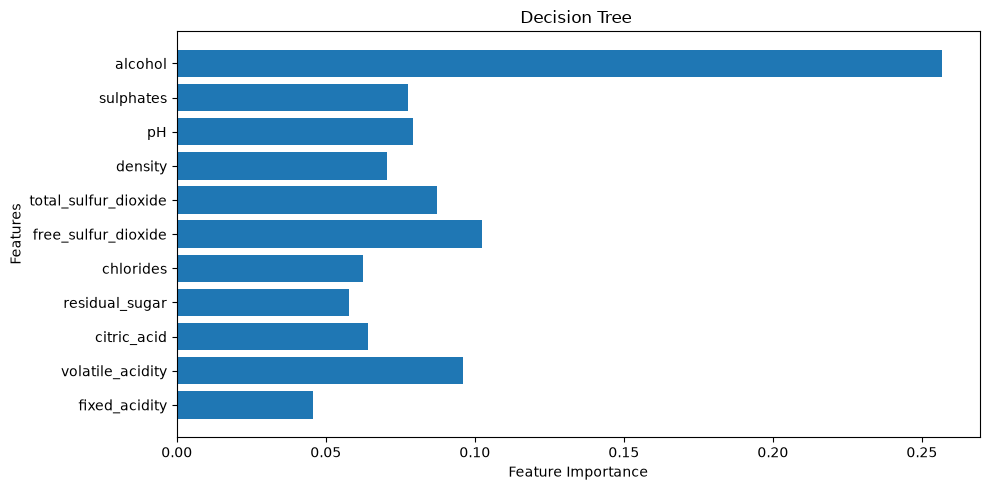

In [27]:
# plotting feature Importance

def plot_feature_importance(name, model):
    plt.figure(figsize=(10, 5))
    n_features = X.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.ylabel('Features')
    plt.xlabel('Feature Importance')
    plt.title(name)
    plt.tight_layout()
    plt.show()

plot_feature_importance('Decision Tree ', tree5)
plt.figure()
plot_feature_importance('Decision Tree ', tree1)

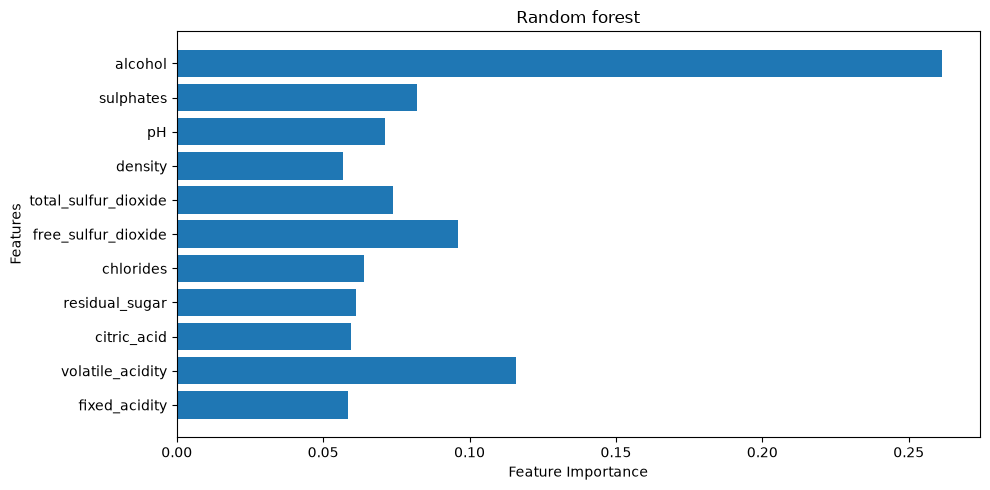

<Figure size 640x480 with 0 Axes>

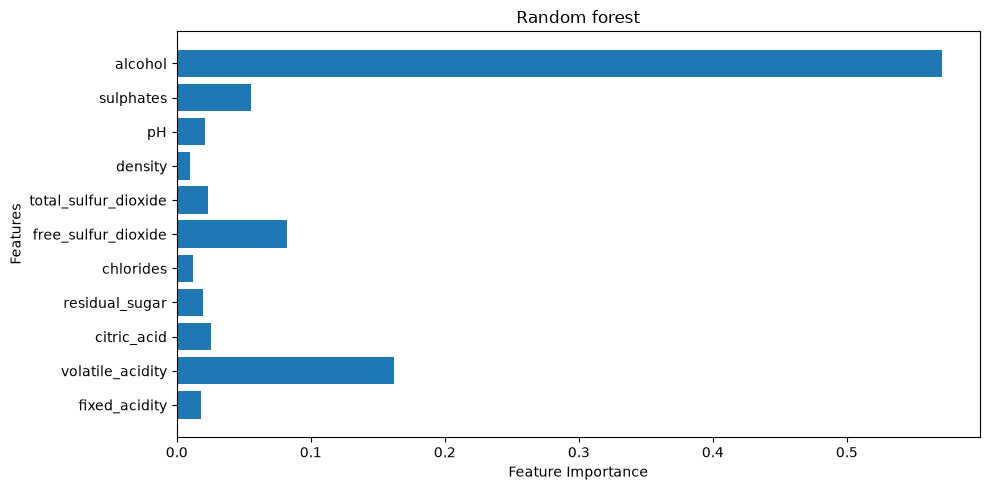

<Figure size 640x480 with 0 Axes>

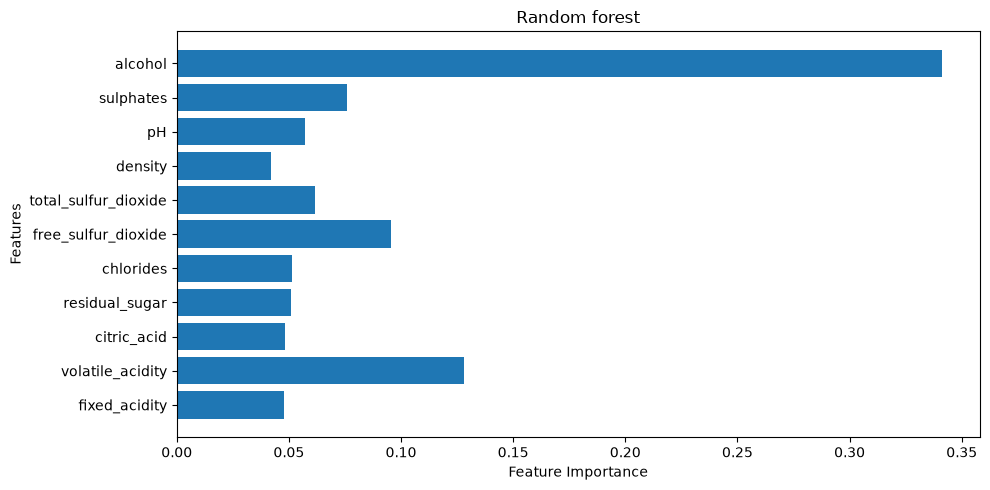

In [28]:
plot_feature_importance('Random forest', forest1)
plt.figure()
plot_feature_importance('Random forest', forest5)
plt.figure()
plot_feature_importance('Random forest', forest9)

In [29]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42)

results=[]

gbr1  = GradientBoostingRegressor()  # default
gbr2  = GradientBoostingRegressor(random_state=42)
gbr3  = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr4  = GradientBoostingRegressor(n_estimators=200, random_state=42)

gbr5  = GradientBoostingRegressor(n_estimators=300, learning_rate=0.01, max_depth=2, random_state=42)
gbr6  = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
gbr7  = GradientBoostingRegressor(n_estimators=300, learning_rate=0.5,  max_depth=8, random_state=42)
gbr8  = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,  max_depth=10, random_state=42)

gbr9  = GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, max_depth=2, random_state=42)
gbr10 = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
gbr11 = GradientBoostingRegressor(n_estimators=500, learning_rate=0.5,  max_depth=8, random_state=42)
gbr12 = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1,  max_depth=10, random_state=42)

gbr13 = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01, max_depth=2, random_state=42)
gbr14 = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, random_state=42)
gbr15 = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.5,  max_depth=8, random_state=42)
gbr16 = GradientBoostingRegressor(n_estimators=1000, learning_rate=0.1,  max_depth=10, random_state=42)

models = {
    "GBRT default": gbr1,
    "GBRT default (rs=42)": gbr2,
    "GBRT 100 trees": gbr3,
    "GBRT 200 trees": gbr4,

    "GBRT 300 trees, lr=0.01, depth=2": gbr5,
    "GBRT 300 trees, lr=0.05, depth=5": gbr6,
    "GBRT 300 trees, lr=0.5, depth=8": gbr7,
    "GBRT 300 trees, lr=0.1, depth=10": gbr8,

    "GBRT 500 trees, lr=0.01, depth=2": gbr9,
    "GBRT 500 trees, lr=0.05, depth=5": gbr10,
    "GBRT 500 trees, lr=0.5, depth=8": gbr11,
    "GBRT 500 trees, lr=0.1, depth=10": gbr12,

    "GBRT 1000 trees, lr=0.01, depth=2": gbr13,
    "GBRT 1000 trees, lr=0.01, depth=5": gbr14,
    "GBRT 1000 trees, lr=0.5, depth=8": gbr15,
    "GBRT 1000 trees, lr=0.1, depth=10": gbr16,
}


for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae= mean_absolute_error(y_test, pred)
    rmse= np.sqrt(mean_squared_error(y_test, pred))
    r2= r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

gbr_table = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
gbr_table

,Model,MAE,RMSE,R2
0,GBRT default,0.524219,0.687271,0.370354
1,GBRT default (rs=42),0.524186,0.687159,0.370560
2,GBRT 100 trees,0.524186,0.687159,0.370560
3,GBRT 200 trees,0.521208,0.685590,0.373431
4,"GBRT 300 trees, lr=0.01, depth=2",0.561639,0.722584,0.303988
5,"GBRT 300 trees, lr=0.05, depth=5",0.518471,0.681247,0.381343
6,"GBRT 300 trees, lr=0.5, depth=8",0.573718,0.758357,0.233366
7,"GBRT 300 trees, lr=0.1, depth=10",0.527215,0.706390,0.334835
8,"GBRT 500 trees, lr=0.01, depth=2",0.548802,0.708949,0.330007
9,"GBRT 500 trees, lr=0.05, depth=5",0.522255,0.683942,0.376439
